## Methods to handle imbalance data

### 1.Upscaling 
### 2.Downscaling

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

n_sample = 1000
class_0_ratio = 0.9
n_class_0 = int(n_sample *class_0_ratio)
n_class_1 = n_sample - n_class_0

In [7]:
class_0 = pd.DataFrame({
    'Feature_1': np.random.normal(loc= 0 , scale = 1 , size = n_class_0),
    'Feature_2':np.random.normal(loc=0,scale = 1, size = n_class_0),
    'target': [0]*n_class_0
})
class_1 = pd.DataFrame({
    'Feature_1': np.random.normal(loc= 2 , scale = 1 , size = n_class_1),
    'Feature_2':np.random.normal(loc=2,scale = 1, size = n_class_1),
    'target': [1]*n_class_1
})

In [8]:
df = pd.concat([class_0,class_1]).reset_index(drop = True)

In [9]:
df.head()

,Feature_1,Feature_2,target
0,-0.675178,-0.045512,0
1,-0.144519,-0.424236,0
2,-0.792420,-0.569833,0
3,-0.307962,0.329509,0
4,-1.893615,-1.517174,0


In [10]:
df.tail()

,Feature_1,Feature_2,target
995,3.001632,2.028458,1
996,3.393455,-0.077812,1
997,2.710549,1.679702,1
998,2.429341,3.643378,1
999,2.379640,2.360648,1


### upsampling

In [13]:
df_minority=df[df['target']==1]
df_majority=df[df['target']==0]

In [18]:
!pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.0 MB 7.4 MB/s eta 0:00:01
   ------------- -------------------------- 2.6/8.0 MB 6.3 MB/s eta 0:00:01
   ------------------- -------------------- 3.9/8.0 MB 6.7 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.0 MB 6.8 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.0 MB 6.8 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 6.5 MB/s  0:00:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/36.3 MB ? eta -:--:--
   - -------------------------------------- 1.3/36.3 MB 6.7 MB/s eta 0:00:06
   --- ------------------------------------ 2.9/36.3 MB 7.0 MB/s eta 0:00:05
   ---- ----------------------------------- 4.2/36.3 MB 7.0 MB/s eta 0

In [27]:
from sklearn.utils import resample
df_minority_upsampled = resample(df_minority,replace=True,  #with replacement edit the current dataframe 
        n_samples= len(df_majority),
        random_state= 42
)

In [34]:
len(df_majority)

900

In [33]:

df_minority_upsampled.head()

,Feature_1,Feature_2,target
951,2.493655,1.165718,1
992,1.200059,0.024512,1
914,0.735502,0.500984,1
971,2.157761,0.897730,1
960,1.548051,1.268368,1


In [ ]:
df_minority_upsampled
.tail()

,Feature_1,Feature_2,target
952,3.296063,4.184097,1
965,1.271538,2.363116,1
976,2.950016,2.506241,1
942,2.978890,1.403026,1
974,1.260629,2.355669,1


In [36]:
df_minority_upsampled

,Feature_1,Feature_2,target
951,2.493655,1.165718,1
992,1.200059,0.024512,1
914,0.735502,0.500984,1
971,2.157761,0.897730,1
960,1.548051,1.268368,1
...,...,...,...
952,3.296063,4.184097,1
965,1.271538,2.363116,1
976,2.950016,2.506241,1
942,2.978890,1.403026,1


In [37]:
df_upsampled = pd.concat([df_majority,df_minority_upsampled])

In [39]:
df_upsampled['target'].value_counts()

target
0    900
1    900
Name: count, dtype: int64

## Down sampling

In [40]:
df_minority=df[df['target']==1]
df_majority=df[df['target']==0]

In [41]:
from sklearn.utils import resample
df_majority_downsampled = resample(df_majority,replace=False,  #with replacement edit the current dataframe 
        n_samples= len(df_minority),
        random_state= 42
)

In [42]:
df_majority_downsampled.shape

(100, 3)

In [43]:
df_downsampled = pd.concat([df_minority,df_majority_downsampled])

In [44]:
df_downsampled.target.value_counts()

target
1    100
0    100
Name: count, dtype: int64

## SMOTE
### SMOTE (syntheic Minority over-smapling technique) is a technique used  in machine learning to address imbalance dataset where the minority class has significantly fewer instances than the majority class .SMOTE involves gernerating synthetic instances of the minority class by interpolating between exsiting instances


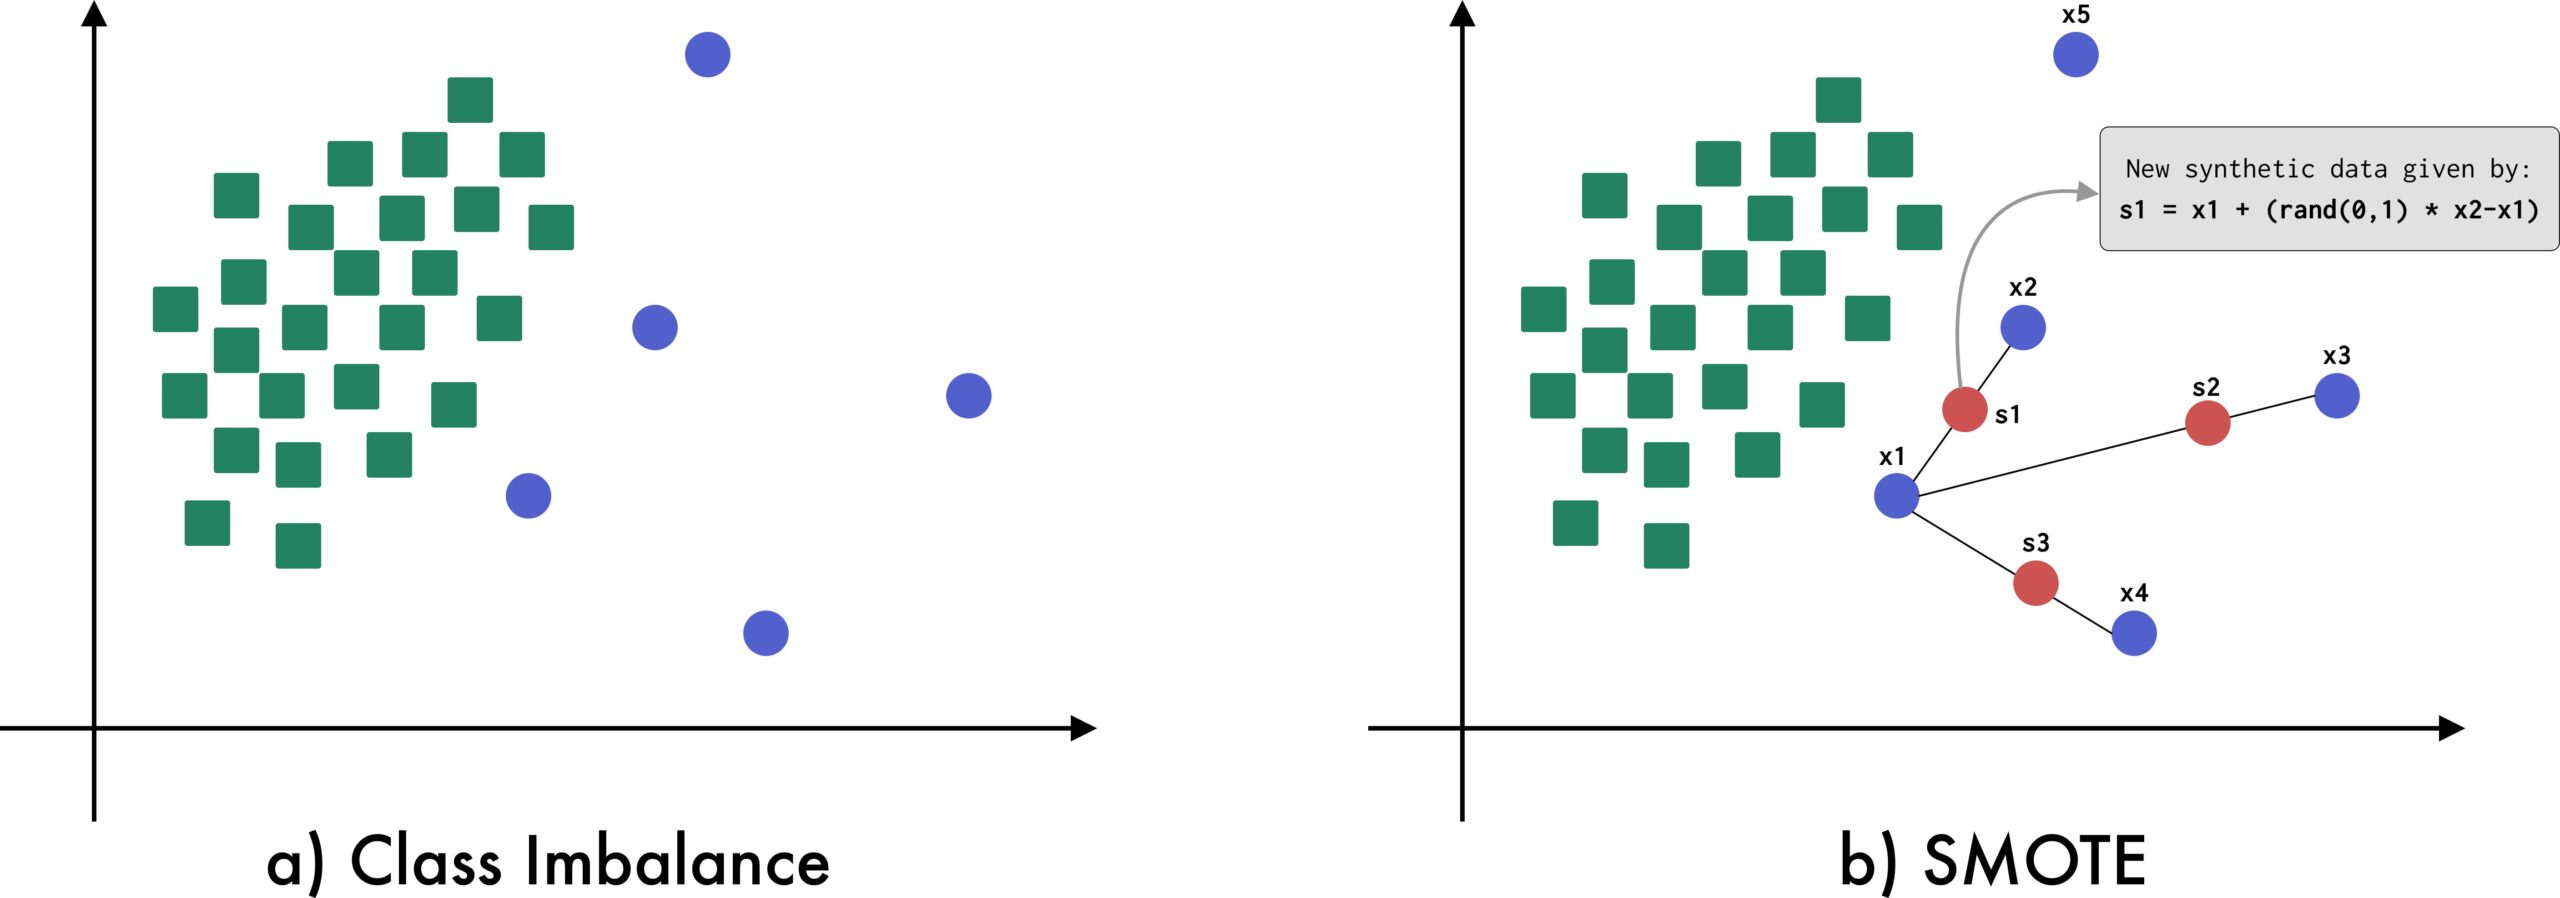

In [1]:
from sklearn.datasets import make_classification

In [3]:
X,y=make_classification(n_samples= 1000,n_features=2,n_clusters_per_class=1,weights=[0.90],n_redundant=0,random_state=12)

In [13]:
import pandas as pd
df1 = pd.DataFrame(X,columns=['f1','f2'] )
df2 = pd.DataFrame(y,columns=['target'])
final_df = pd.concat([df1,df2],axis=1)
final_df

,f1,f2,target
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0
...,...,...,...
995,-0.712495,-0.880452,0
996,-2.625830,-2.827891,0
997,-1.326439,-1.815178,0
998,-0.833486,-0.514647,0


In [14]:
final_df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

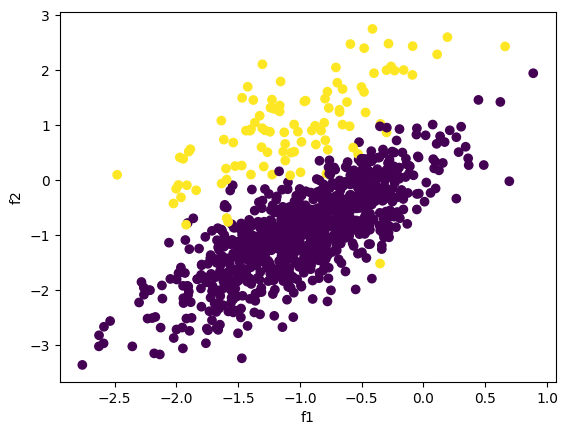

In [29]:
import matplotlib.pyplot as plt
plt.scatter(final_df['f1'], final_df['f2'],c=final_df['target'])
plt.xlabel('f1')
plt.ylabel('f2')
plt.show()

In [16]:
!pip install imblearn


   ---------------------------------------- 0/3 [sklearn-compat]
   ---------------------------------------- 0/3 [sklearn-compat]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn

In [17]:
from imblearn.over_sampling import SMOTE

In [18]:
overSample = SMOTE()
X,y = overSample.fit_resample(final_df[['f1','f2']],final_df['target'])

In [19]:
X.shape

(1800, 2)

In [20]:
y.shape

(1800,)

In [26]:
y[y==1].value_counts

<bound method IndexOpsMixin.value_counts of 3       1
19      1
26      1
34      1
39      1
       ..
1795    1
1796    1
1797    1
1798    1
1799    1
Name: target, Length: 900, dtype: int64>

In [27]:
y[y==0].value_counts

<bound method IndexOpsMixin.value_counts of 0      0
1      0
2      0
4      0
5      0
      ..
995    0
996    0
997    0
998    0
999    0
Name: target, Length: 900, dtype: int64>

In [33]:
df1 = pd.DataFrame(X,columns=['f1', 'f2'])
df2 = pd.DataFrame(y,columns=['target'])
overSample_df = pd.concat([df1,df2],axis=1)

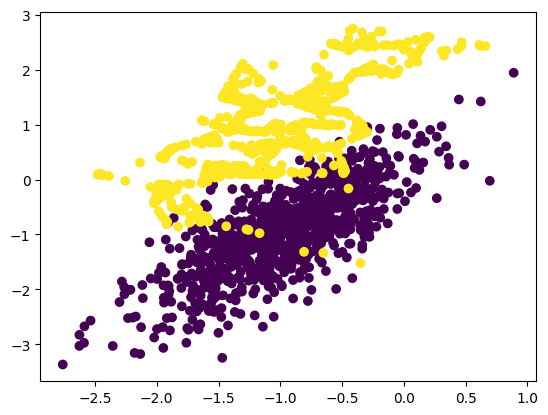

In [34]:
plt.scatter(overSample_df['f1'],overSample_df['f2'],c=overSample_df['target'])

## 5 number Summary and Box plot

#### minimum, maximum , median, Q1,Q3,IQR

In [37]:
import numpy as np

In [49]:
lst_marks=[22,34,24,62,64,45,7,32,46,89,99,100,233,23,45,67,78,33,66,36,36,47,54,34,57,46,38,94,65,74,45,453,8,43,73,56,45,47,65,45,345,363,352,245,435,274]

minimum,Q1,median,Q3,maximun= np.quantile(lst_marks,[0,0.25,0.50,0.75,1.0])

In [50]:

minimum,Q1,median,Q3,maximun

(np.float64(7.0),
 np.float64(39.25),
 np.float64(55.0),
 np.float64(86.25),
 np.float64(453.0))

In [51]:
IQR = Q3-Q1

In [52]:
lower_fence = Q1 - 1.5*IQR
higher_fence = Q3 +1.5 *IQR

In [53]:
lower_fence,higher_fence

(np.float64(-31.25), np.float64(156.75))

In [54]:
import seaborn as sns

<Axes: >

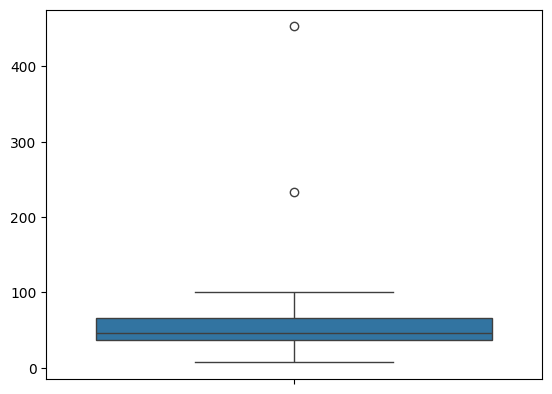

In [48]:
sns.boxplot(lst_marks)

In [57]:
lst_marks = np.array(lst_marks)
remove_outlier = lst_marks[(lst_marks>lower_fence) & (lst_marks<higher_fence)]

<Axes: >

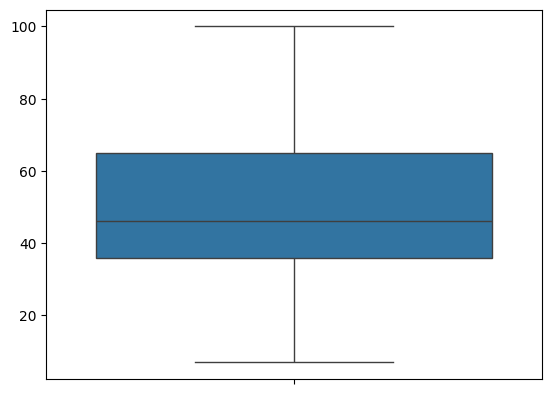

In [58]:
sns.boxplot(remove_outlier)

# Data Encoding

##### Nominal encoding, commonly performed using One-Hot Encoding (OHE), is a technique used to convert nominal categorical data, which has no natural order or ranking, into numerical form so it can be used in machine learning models. Examples of nominal data include gender, color, city, and country. One-Hot Encoding works by creating separate binary (0/1) columns for each category, ensuring that all categories are treated equally and no false ordering is introduced. This method is widely used because it is simple, interpretable, and works well with most machine learning algorithms, especially linear and distance-based models. However, OHE increases dimensionality when a feature has many unique categories and can lead to the dummy variable trap (multicollinearity), which is usually avoided by dropping one encoded column. Overall, nominal encoding with OHE is best suited for nominal features with a limited number of categories and is a standard preprocessing technique in data analysis and machine learning.

##### When to Use
##### 1.Nominal categorical features
##### 2.Linear regression, logistic regression, KNN, SVM

### example
| Color_Red | Color_Blue | Color_Green |
| --------- | ---------- | ----------- |
| 1         | 0          | 0           |
| 0         | 1          | 0           |
| 0         | 0          | 1           |


In [60]:
from sklearn.preprocessing import OneHotEncoder

In [61]:
import pandas as pd
df = pd.DataFrame({
    'color' :['red','blue','red','green' , 'blue',]
})

In [62]:
df.head()

,color
0,red
1,blue
2,red
3,green
4,blue


In [63]:
#creating instance of onehotencoding
encoder = OneHotEncoder()

In [80]:
encoded=encoder.fit_transform(df[['color']]).toarray()

In [67]:
import pandas as pd

In [69]:
encoder_df = pd.DataFrame(encoded,columns=encoder.get_feature_names_out())

In [70]:
encoder_df

,color_blue,color_green,color_red
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,0.0,1.0
3,0.0,1.0,0.0
4,1.0,0.0,0.0


In [72]:
## For new data
encoder.transform([['blue']]).toarray()

d:\udemy\ML\venv1\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


array([[1., 0., 0.]])

In [74]:
pd.concat([df,encoder_df],axis=1)

,color,color_blue,color_green,color_red
0,red,0.0,0.0,1.0
1,blue,1.0,0.0,0.0
2,red,0.0,0.0,1.0
3,green,0.0,1.0,0.0
4,blue,1.0,0.0,0.0


In [81]:
import seaborn as sns
df = sns.load_dataset('tips')

In [82]:
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [83]:
encoder = OneHotEncoder()


In [85]:
encoded = encoder.fit_transform(df[['sex']]).toarray()

In [90]:
encoded_df1 = pd.DataFrame(encoded, columns=encoder.get_feature_names_out())

In [92]:
encoded_df1

,sex_Female,sex_Male
0,1.0,0.0
1,0.0,1.0
2,0.0,1.0
3,0.0,1.0
4,1.0,0.0
...,...,...
239,0.0,1.0
240,1.0,0.0
241,0.0,1.0
242,0.0,1.0


In [101]:
df = pd.concat([df,encoded_df1],axis=1)

In [95]:
df['time'].unique()

['Dinner', 'Lunch']
Categories (2, str): ['Lunch', 'Dinner']

In [98]:
encoded_time_arrya = encoder.fit_transform(df[['time']]).toarray()

In [99]:
time_df = pd.DataFrame(encoded_time_arrya,columns=encoder.get_feature_names_out())

In [100]:
time_df

,time_Dinner,time_Lunch
0,1.0,0.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,1.0,0.0
...,...,...
239,1.0,0.0
240,1.0,0.0
241,1.0,0.0
242,1.0,0.0


In [102]:
df = pd.concat([df,time_df],axis=1)

In [103]:
df

,total_bill,tip,sex,smoker,day,time,size,sex_Female,sex_Male,time_Dinner,time_Lunch
0,16.99,1.01,Female,No,Sun,Dinner,2,1.0,0.0,1.0,0.0
1,10.34,1.66,Male,No,Sun,Dinner,3,0.0,1.0,1.0,0.0
2,21.01,3.50,Male,No,Sun,Dinner,3,0.0,1.0,1.0,0.0
3,23.68,3.31,Male,No,Sun,Dinner,2,0.0,1.0,1.0,0.0
4,24.59,3.61,Female,No,Sun,Dinner,4,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,0.0,1.0,1.0,0.0
240,27.18,2.00,Female,Yes,Sat,Dinner,2,1.0,0.0,1.0,0.0
241,22.67,2.00,Male,Yes,Sat,Dinner,2,0.0,1.0,1.0,0.0
242,17.82,1.75,Male,No,Sat,Dinner,2,0.0,1.0,1.0,0.0


## Label Encoding
### Label Encoding is a technique to convert categorical text data into numerical labels by assigning a unique integer to each category. It is useful for ordinal data or models that can handle integer categories.

In [104]:
from sklearn.preprocessing import LabelEncoder
lblEncoder= LabelEncoder()


In [105]:
df = pd.DataFrame({'color': ['red', 'blue', 'green', 'blue']})

In [109]:
encoded  = lblEncoder.fit_transform(df[['color']])

d:\udemy\ML\venv1\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [111]:
encoded_df = pd.DataFrame(encoded)

In [113]:
pd.concat([df,encoded_df],axis=1)

,color,0
0,red,2
1,blue,0
2,green,1
3,blue,0


## Ordinal Encoding

### Definition:
    Ordinal Encoding is a technique used to convert categorical variables with a meaningful order (ordinal data) into numeric values. Unlike nominal data, ordinal data has a natural ranking, so numbers assigned should reflect that order.

### Examples of ordinal data:

Education level: High School < Bachelor < Master < PhD

Customer satisfaction: Low < Medium < High < Very High

Clothing sizes: Small < Medium < Large < Extra Large

In [122]:
from sklearn.preprocessing import OrdinalEncoder
#instance of odinal encoder and then fit_transform
od_encoder = OrdinalEncoder(categories=[['Small','Medium', 'Large']]) 

In [120]:
df = pd.DataFrame({'Size': ['Small', 'Medium', 'Large', 'Small']})

In [119]:
df

,Size
0,Small
1,Medium
2,Large
3,Small


In [123]:
od_encoder.fit_transform(df[['Size']])

array([[0.],
       [1.],
       [2.],
       [0.]])

In [124]:
od_encoder.transform([['Large']])

d:\udemy\ML\venv1\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(


array([[2.]])

## Target-Guided Ordinal Encoding

### Definition:
    Target-Guided Ordinal Encoding is a method of encoding categorical features based on the relationship between the feature and the target variable. Instead of arbitrary numbers or one-hot columns, categories are assigned numbers according to their effect on the target (e.g., the mean of the target for each category).

    It is especially useful for high-cardinality categorical variables in regression or classification tasks.

In [125]:
df = pd.DataFrame({
    'Color': ['Red', 'Blue', 'Green', 'Red', 'Blue'],
    'Target': [1, 0, 0, 1, 1]
})

In [126]:
df

,Color,Target
0,Red,1
1,Blue,0
2,Green,0
3,Red,1
4,Blue,1


In [127]:
mean_target =df.groupby('Color')['Target'].mean().to_dict()

In [128]:
mean_target

{'Blue': 0.5, 'Green': 0.0, 'Red': 1.0}

In [130]:
df['Color_encoded'] = df['Color'].map(mean_target)

In [131]:
df

,Color,Target,Color_encoded
0,Red,1,1.0
1,Blue,0,0.5
2,Green,0,0.0
3,Red,1,1.0
4,Blue,1,0.5


In [133]:
df[['Target','Color_encoded']]

,Target,Color_encoded
0,1,1.0
1,0,0.5
2,0,0.0
3,1,1.0
4,1,0.5


In [134]:
import seaborn as sns
df = sns.load_dataset('tips')

In [135]:
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


### convert time w.r.t to total bill